In [1]:
# load lib
library(tidyverse)
library(glmnet)
library(glmmTMB)
library(caret)
library(DHARMa)
library(readr)
library(dplyr)
library(janitor)

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘glmnet’ was built under R version 4.4.1”
Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10

Warning message:
“package ‘glmmTM

In [2]:
drop_redundant_yn_features <- function(df) {
  # Get all column names
  cols <- names(df)
  
  # Find Yes/No pairs by stripping the suffix
  # Pattern: variable name ends in " - Yes" or " - No"
  yes_cols <- cols[grepl("_yes$", cols)]
  no_cols  <- cols[grepl("_no$",  cols)]
  
  # Get base names for each
  yes_bases <- sub("_yes$", "", yes_cols)
  no_bases  <- sub("_no$",  "", no_cols)
  
  # Find bases that have BOTH a Yes and No column
  paired_bases <- intersect(yes_bases, no_bases)
  
  cols_to_drop <- c()
  
  for (base in paired_bases) {
    yes_col <- yes_cols[yes_bases == base]
    no_col  <- no_cols[no_bases == base]
    
    # Count NAs in each
    yes_nas <- sum(is.na(df[[yes_col]]))
    no_nas  <- sum(is.na(df[[no_col]]))
    
    # Drop whichever has more NAs; if tied, drop "No" (keep "Yes")
    if (no_nas >= yes_nas) {
      cols_to_drop <- c(cols_to_drop, no_col)
    } else {
      cols_to_drop <- c(cols_to_drop, yes_col)
    }
  }
  
  cat("Dropping", length(cols_to_drop), "redundant columns:\n")
  #cat(paste(" ", cols_to_drop), sep = "\n")
  
  df[, !names(df) %in% cols_to_drop]
}

set.seed(100)

df <- read_csv("data/merged_with_svi.csv", show_col_types = FALSE) |> clean_names() 
#df <- read_csv("data/merged_with_svi.csv") |> clean_names()

# outbreak >=2 is with outbreak, vice versa.
# df$outbreak <- as.integer(df$outbreak >= def_outbreak)

# SVI specific, because it does not include the data for Mcculloch, Mclennan, Mcmullen and Dewitt, 
# if we continue the prev way of data processing it will remove all SVI related features, so we remove these 4 counties.
#df <- df[!df$county %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt"), ]

df <- df %>% filter(!county %in% c("Mcculloch", "Mclennan", "Mcmullen", "Dewitt", "Loving"))
df_raw <- df
df$density <- df$population*1.0/df$area_sqmi
df <- df %>% dplyr::select(-c("county", "area_sqmi"), -starts_with("m_"), -starts_with("mp_"), -starts_with("e_"), -starts_with("epl_"), -starts_with("spl_"), -starts_with("rpl_"), -starts_with("f_"))
df <- df[,colSums(is.na(df)) == 0]
df <- df %>% dplyr::select(-c("ep_minrty", "ep_hisp", "ep_afam", "ep_pov150", "ep_uninsur"))

df <- drop_redundant_yn_features(df)

# split the data with stratified sampling
# strata <- ifelse(df$outbreak > 0, "nonzero", "zero")
index <- createDataPartition(df$outbreak, p = 0.75, list = FALSE)
train <- df[index,]
test <- df[-index,]
PHR <- train$phr
offset <- log10(train$enrollment)
outbreak <- train$outbreak
train <- train %>% dplyr::select(-c("phr", "enrollment", "population", "outbreak"))

Dropping 55 redundant columns:


In [3]:
X <- as.matrix(train)
y <- outbreak
# X <- X[, abs(cor(X, y , use = "complete.obs", method = "spearman")) >= 0.1]

# Start with full list of candidates
candidates <- colnames(X)

i <- 1
while (i < length(candidates)) {
  j <- i + 1
  while (j <= length(candidates)) {
    rho <- cor(X[, candidates[i]], X[, candidates[j]], 
               method = "spearman", use = "complete.obs")
    if (abs(rho) >= 0.7) {
      # Drop whichever has weaker correlation with outcome
      rho_i <- abs(cor(X[, candidates[i]], y, method = "spearman", use = "complete.obs"))
      rho_j <- abs(cor(X[, candidates[j]], y, method = "spearman", use = "complete.obs"))
      if (rho_i >= rho_j) {
        candidates <- candidates[-j]  
      } else {
        candidates <- candidates[-i]  
        j <- i + 1
      }
    } else {
      j <- j + 1
    }
  }
  i <- i + 1
}

X <- X[, candidates]
X

cve,pct_black,pct_poverty,pct_uninsured,pct_college,pct_foreign_born,asthma_status_never,bmi_3_categories_recommended_range,clnscpy_sgmscpy_colonoscopy,dr_rx_pain_talk_yes,⋯,ep_crowd,ep_noveh,ep_groupq,ep_noint,ep_asian,ep_aian,ep_nhpi,ep_twomore,ep_otherrace,density
2.54,18.6,13.5,18.5,15.4,1.1,85.1,25.4,83.3,64.2,⋯,5.1,6.5,21.7,17.8,0.7,0.7,0.1,4.7,0.2,56.749551
1.91,1.6,14.2,22.4,17.7,1.2,85.9,21.7,82.0,70.4,⋯,5.5,1.6,0.7,9.2,0.5,0.0,0.0,0.8,0.1,13.208987
2.06,1.3,10.7,12.8,28.8,1.5,90.4,27.0,77.9,49.3,⋯,5.1,5.1,1.4,10.6,1.7,0.5,0.0,2.2,0.0,102.920403
2.70,1.5,4.5,13.9,25.4,0.8,86.0,30.0,88.6,58.2,⋯,1.7,2.5,0.8,16.8,0.2,0.4,0.0,3.1,0.0,9.937021
1.08,1.2,13.6,19.5,15.7,1.2,82.4,28.7,84.6,59.1,⋯,8.1,5.5,0.9,15.3,0.5,0.0,0.0,1.5,0.1,42.896443
3.55,7.9,10.6,16.7,25.1,1.1,86.0,32.5,87.8,48.8,⋯,5.7,3.5,1.0,19.4,0.5,0.1,0.0,2.1,0.4,50.979487
3.78,1.2,8.5,13.3,27.2,1.5,82.4,28.7,84.6,59.1,⋯,3.9,1.5,2.2,12.1,0.5,0.5,0.0,2.9,0.6,28.973700
2.09,5.8,7.0,21.8,25.0,1.4,84.4,34.1,86.3,62.1,⋯,4.1,2.9,2.5,15.6,0.7,0.1,0.0,3.2,0.3,131.545103
0.88,1.2,16.0,20.6,25.3,1.6,86.0,30.0,88.6,58.2,⋯,3.6,3.1,2.3,18.1,0.0,0.2,1.1,5.8,0.0,4.068104
1.48,7.3,11.8,18.8,14.0,0.8,90.4,27.0,77.9,49.3,⋯,3.7,5.0,23.7,24.4,0.6,0.3,0.0,3.1,0.2,34.223660


In [4]:
# Gaussian LASSO 筛选,响应 log(count+1),不加 offset
set.seed(100)
cv.lasso <- cv.glmnet(X, log10(y + 1), family = "gaussian", alpha = 1)   # y = log(count+1),你的原变量
best.lambda <- cv.lasso$lambda.min
print(best.lambda)
lasso_coef <- coef(cv.lasso, s = "lambda.min")
lasso_vars <- rownames(lasso_coef)[
  abs(lasso_coef[, 1]) >= 1e-5 & !grepl("Intercept", rownames(lasso_coef))
]
lasso_vars

[1] 0.02837971


[1] "cve"                                       
 [2] "pct_uninsured"                             
 [3] "bmi_3_categories_recommended_range"        
 [4] "last_dentist_visit_within_the_past_2_years"
 [5] "mammogram_past_2_yrs_40_ia_yes"            
 [6] "routine_checkup_within_the_past_2_years"   
 [7] "routine_checkup_within_the_past_year"      
 [8] "skin_cancer_no"                            
 [9] "ep_hburd"                                  
[10] "ep_nohsdp"                                 
[11] "ep_age65"                                  
[12] "ep_munit"

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”


 Family: nbinom2  ( log )
Formula:          
cases ~ cve + pct_uninsured + bmi_3_categories_recommended_range +  
    last_dentist_visit_within_the_past_2_years + mammogram_past_2_yrs_40_ia_yes +  
    routine_checkup_within_the_past_2_years + routine_checkup_within_the_past_year +  
    skin_cancer_no + ep_hburd + ep_nohsdp + ep_age65 + ep_munit +  
    offset(log(enrollment)) + (1 | PHR)
Zero inflation:         ~1
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
       NA        NA        NA        NA       171 

Random effects:

Conditional model:
 Groups Name        Variance  Std.Dev. 
 PHR    (Intercept) 8.151e-33 9.028e-17
Number of obs: 187, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.224 

Conditional model:
                                            Estimate Std. Error z value
(Intercept)                                -24.64571        NaN     NaN
cve                                          0.48263        NaN     NaN
pct_uninsured       

 Family: nbinom2  ( log )
Formula:          
cases ~ cve + pct_uninsured + bmi_3_categories_recommended_range +  
    last_dentist_visit_within_the_past_2_years + mammogram_past_2_yrs_40_ia_yes +  
    routine_checkup_within_the_past_2_years + routine_checkup_within_the_past_year +  
    skin_cancer_no + ep_hburd + ep_nohsdp + ep_age65 + ep_munit +  
    offset(log(enrollment))
Data: model_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    267.7     312.9    -119.8     239.7       173 


Dispersion parameter for nbinom2 family (): 0.224 

Conditional model:
                                            Estimate Std. Error z value
(Intercept)                                -24.64517   32.12202  -0.767
cve                                          0.48263    0.17813   2.709
pct_uninsured                               -0.07343    0.09647  -0.761
bmi_3_categories_recommended_range          -0.10721    0.14577  -0.735
last_dentist_visit_within_the_past_2_years   0.08283    0.13617   0.

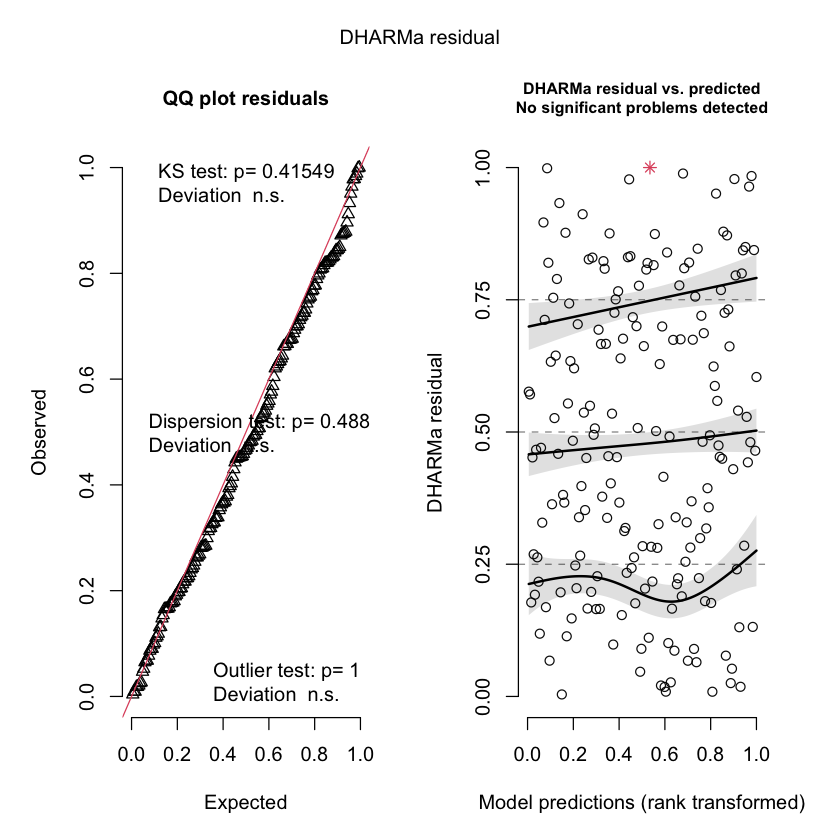


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.1508, p-value = 0.488
alternative hypothesis: two.sided


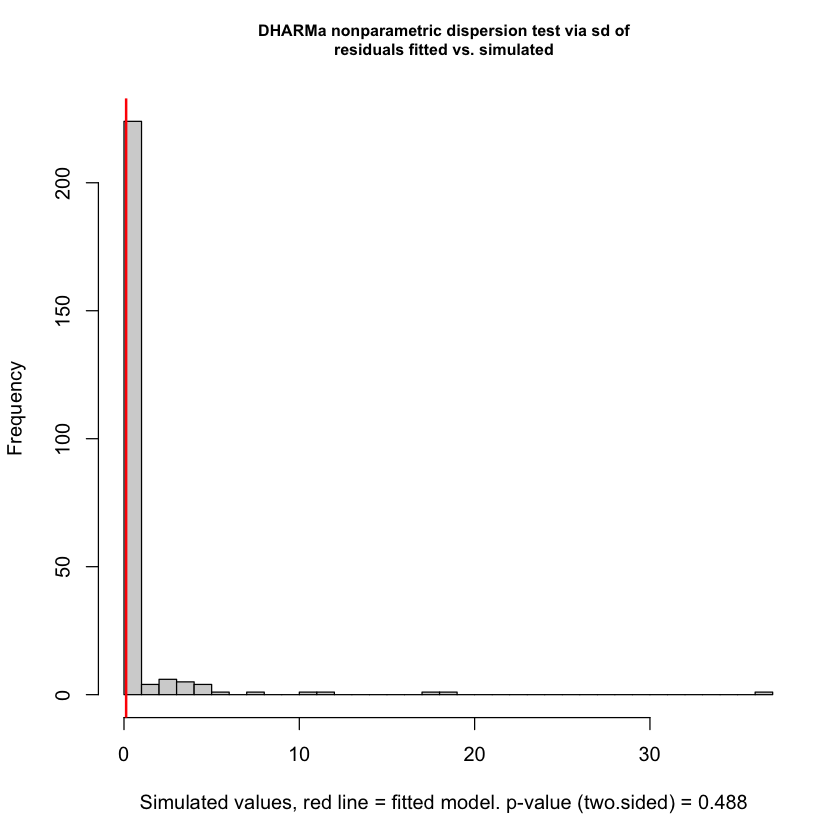


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 1.0061, p-value = 0.912
alternative hypothesis: two.sided


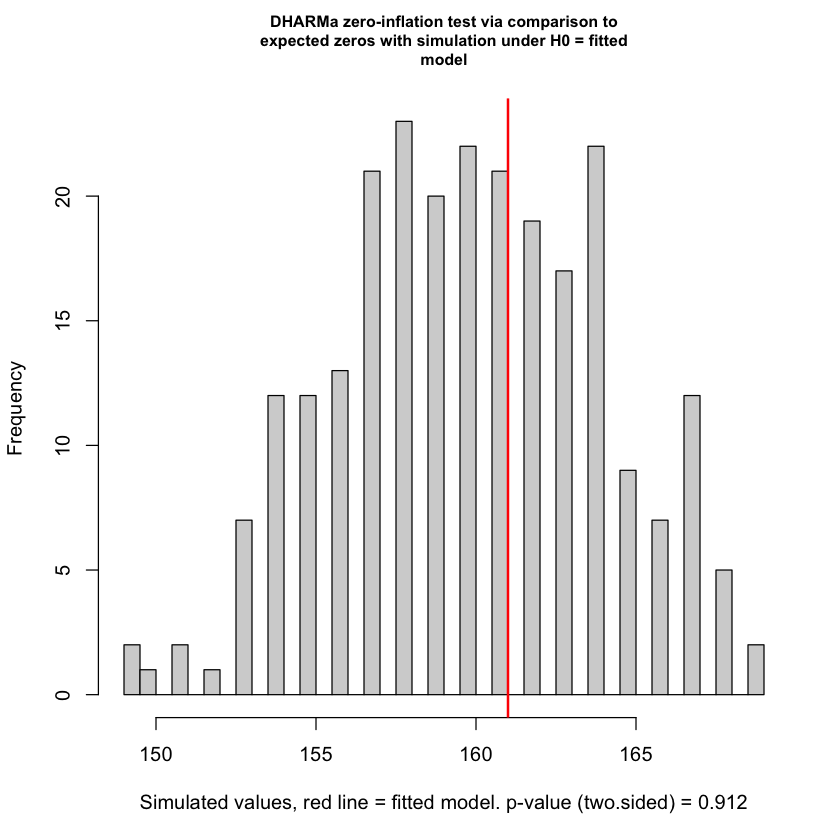


	DHARMa bootstrapped outlier test

data:  sim
outliers at both margin(s) = 1, observations = 187, p-value = 1
alternative hypothesis: two.sided
 percent confidence interval:
 0.00000000 0.01069519
sample estimates:
outlier frequency (expected: 0.003475935828877 ) 
                                     0.005347594 


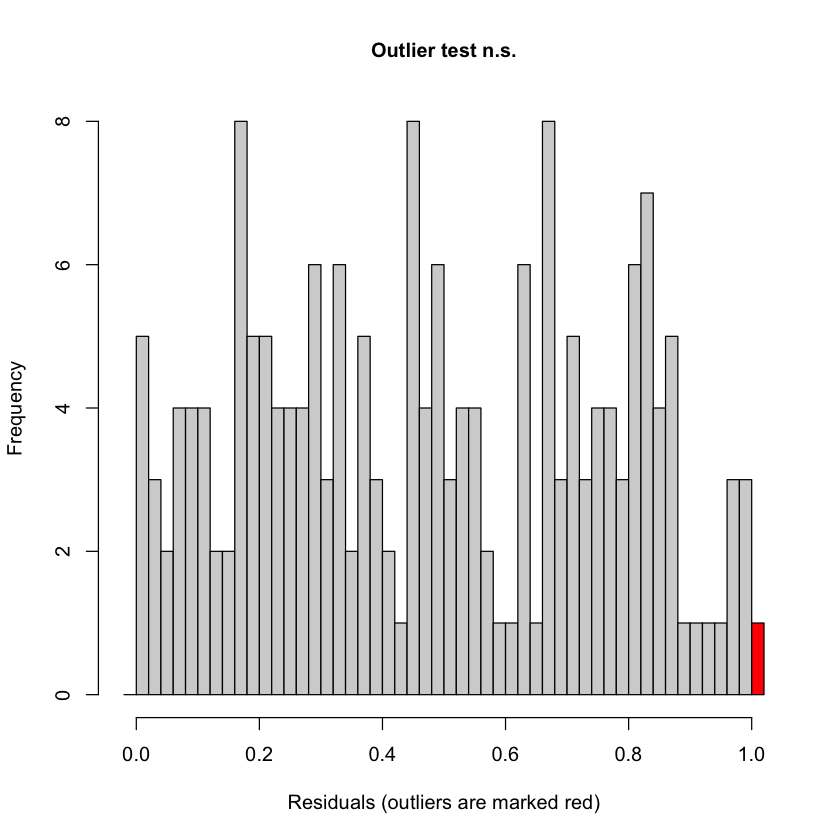

In [5]:
X_f <- X[, lasso_vars, drop = FALSE]
model_df <- cbind(
  data.frame(cases = y, enrollment = exp(offset), PHR = factor(PHR)),
  X_f
)
f <- reformulate(c(lasso_vars, "offset(log(enrollment))", "(1 | PHR)"),
                 response = "cases")

m_zinb <- glmmTMB(f, family = nbinom2, ziformula = ~1, data = model_df)
summary(m_zinb)

# 去掉塌陷的随机效应 + 去掉零膨胀,先看纯 NB 能不能干净收敛
f_fixed <- reformulate(c(lasso_vars, "offset(log(enrollment))"),
                       response = "cases")
m_nb <- glmmTMB(f_fixed, family = nbinom2, data = model_df)
summary(m_nb)

library(DHARMa)
sim <- simulateResiduals(m_nb)
plot(sim)                  # QQ + 残差 vs 预测
testDispersion(sim)        # 确认过离散被 NB 处理干净
testZeroInflation(sim)     # 关键:确认 NB 已吸收零,不需 ZI
testOutliers(sim)

Warning message in obs - preds:
“longer object length is not a multiple of shorter object length”
Warning message in obs - preds:
“longer object length is not a multiple of shorter object length”


RMSE = 4336.148  MAE = 319.686 


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    0.00     0.01     0.07   318.00     0.46 59295.80 

[1] 59295.8

[1] 64

...

[1] 187

[1] 187

[1] 187

,df,AIC
,<dbl>,<dbl>
m_null,2,311.7450
m_nb,14,267.6989


Nagelkerke R² = 0.3779197 


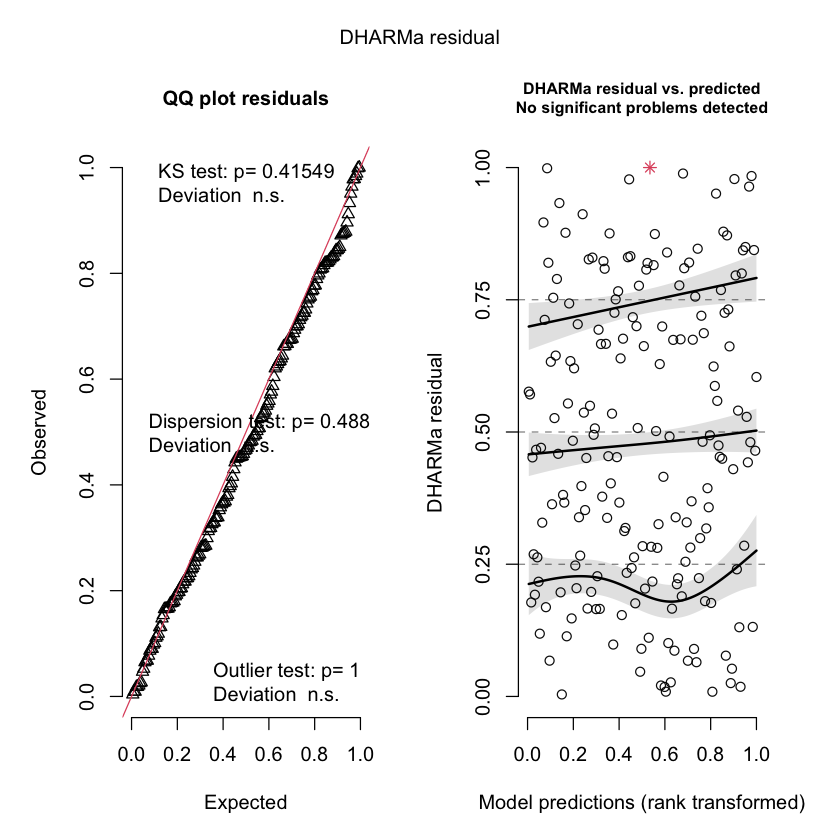


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.1508, p-value = 0.488
alternative hypothesis: two.sided


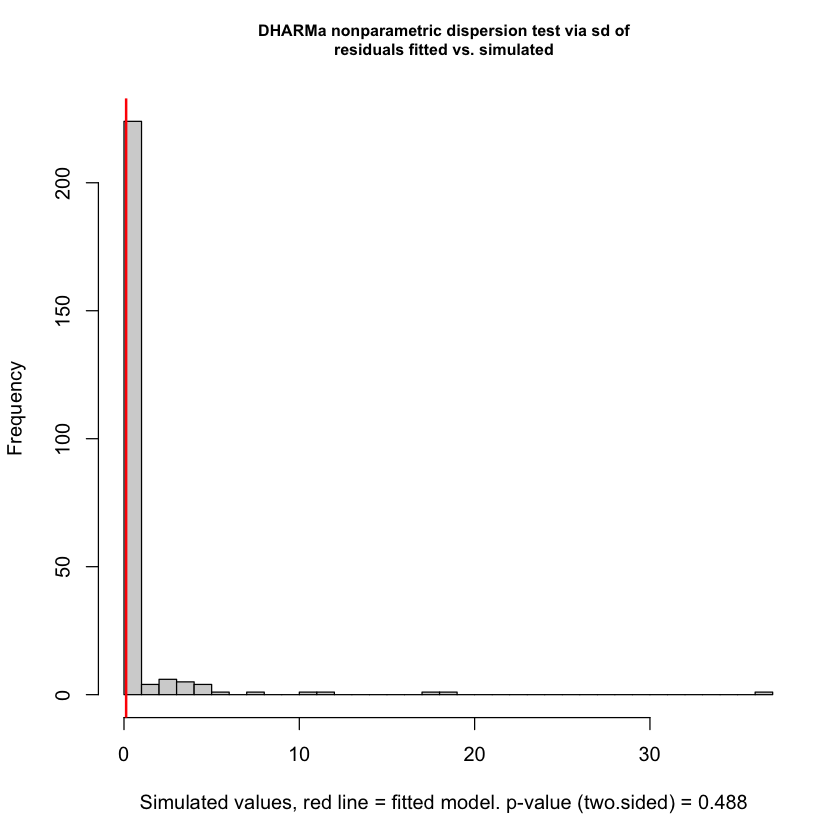


	DHARMa zero-inflation test via comparison to expected zeros with
	simulation under H0 = fitted model

data:  simulationOutput
ratioObsSim = 1.0061, p-value = 0.912
alternative hypothesis: two.sided


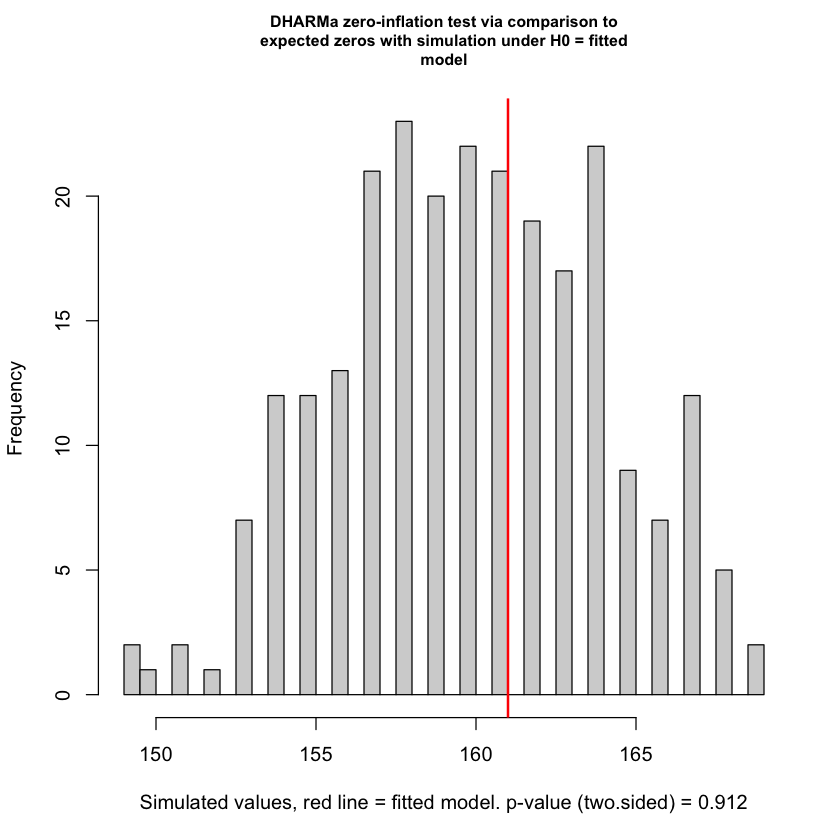


	DHARMa bootstrapped outlier test

data:  sim
outliers at both margin(s) = 1, observations = 187, p-value = 1
alternative hypothesis: two.sided
 percent confidence interval:
 0.00000000 0.01069519
sample estimates:
outlier frequency (expected: 0.003475935828877 ) 
                                     0.005347594 


R² (excl. outlier) = 0.2642368 


[1] 0.2019622

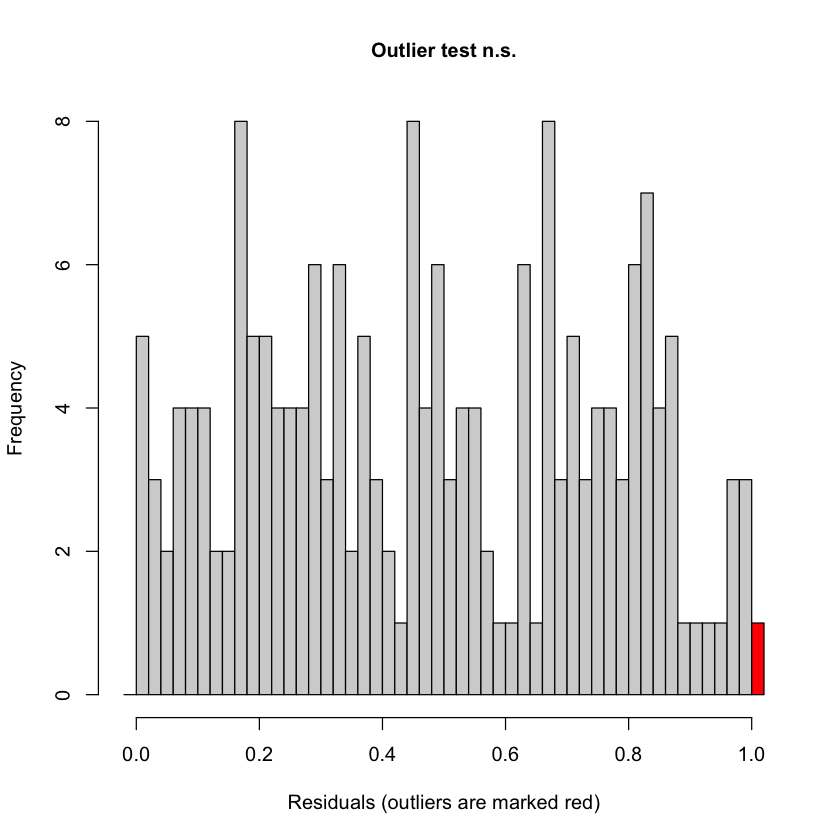

In [17]:
library(glmmTMB)
set.seed(100)
n <- nrow(model_df)
k <- 5
folds <- sample(rep(1:k, length.out = n))
preds <- numeric(n)

for (i in 1:k) {
  tr <- model_df[folds != i, ]
  te <- model_df[folds == i, ]
  fit <- glmmTMB(f_fixed, family = nbinom2, data = tr)
  preds[folds == i] <- predict(fit, newdata = te, type = "response")
}

# 计数预测的合适指标
obs <- test$outbreak
rmse <- sqrt(mean((obs - preds)^2))
mae  <- mean(abs(obs - preds))
cat("RMSE =", rmse, " MAE =", mae, "\n")

summary(preds)
max(preds)
which(preds > 1000)        # 哪些行预测爆了
model_df$enrollment[which(preds > 1000)]   # 看这些行的 enrollment

ok <- preds < 1000
sqrt(mean((obs[ok] - preds[ok])^2))   # 去掉爆炸点的 RMSE
mean(abs(obs[ok] - preds[ok]))        # MAE


# 零模型(仅截距 + offset)
m_null <- glmmTMB(cases ~ 1 + offset(log(enrollment)),
                  family = nbinom2, data = model_df)
mcfadden <- 1 - as.numeric(logLik(m_nb)) / as.numeric(logLik(m_null))
cat("McFadden R² =", mcfadden, "\n")
dev_explained <- 1 - deviance(m_nb) / deviance(m_null)
cat("Deviance explained =", dev_explained, "\n")
nobs(m_nb); nobs(m_null)      # 必须相等

nobs(m_nb); nobs(m_null)           # 先确认行数一致

# AIC 比较(已知可靠)
AIC(m_null, m_nb)                  # full 应明显更低

# 或 Nagelkerke 伪 R²(也基于 likelihood)
n <- nobs(m_nb)
ll_full <- as.numeric(logLik(m_nb))
ll_null <- as.numeric(logLik(m_null))
cox_snell <- 1 - exp((2/n)*(ll_null - ll_full))
nagelkerke <- cox_snell / (1 - exp((2/n)*ll_null))
cat("Nagelkerke R² =", nagelkerke, "\n")
library(DHARMa)
sim <- simulateResiduals(m_nb)
plot(sim)                 # 左图 QQ(KS test)+ 右图残差 vs 预测
testDispersion(sim)       # p>0.05 = 过离散已处理干净
testZeroInflation(sim)    # p>0.05 = 不需要 ZI(印证 AIC 的 NB>ZINB)
testOutliers(sim)         # 大概率标出 414 那个县

preds <- predict(m_nb, type = "response")
obs   <- model_df$cases

ok <- obs != 414
ss_res <- sum((obs[ok] - preds[ok])^2)
ss_tot <- sum((obs[ok] - mean(obs[ok]))^2)
r2 <- 1 - ss_res/ss_tot
cat("R² (excl. outlier) =", r2, "\n")

# Spearman² —— 衡量模型能否正确排序高/低风险县,不被单点主导
cor(obs, preds, method = "spearman")^2

# 或分两段诚实报告(你之前已经算过):
# 全样本 RMSE(被离群点主导) vs 常规县 RMSE≈5



In [ ]:
library(MASS)
null <- glm.nb(reformulate("offset(offset)", "y"), data = model_df)
full <- glm.nb(reformulate(c(lasso_vars, "offset(offset)"), "y"), data = model_df)

lower <- reformulate("offset(offset)", "y")
upper <- formula(full)
both <- stepAIC(null, scope = list(lower = lower, upper = upper),
                direction = "both", trace = FALSE)
summary(both)

Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nich


Call:
glm.nb(formula = y ~ bmi_3_categories_recommended_range + cve + 
    skin_cancer_no + ep_age65 + offset(offset), data = model_df, 
    init.theta = 0.1810651028, link = log)

Coefficients:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        -41.30902   18.38766  -2.247 0.024668 *  
bmi_3_categories_recommended_range  -0.28042    0.07274  -3.855 0.000116 ***
cve                                  0.47032    0.11920   3.946 7.96e-05 ***
skin_cancer_no                       0.47274    0.18109   2.610 0.009042 ** 
ep_age65                            -0.17428    0.06106  -2.854 0.004313 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.1811) family taken to be 1)

    Null deviance: 221.395  on 186  degrees of freedom
Residual deviance:  67.519  on 182  degrees of freedom
AIC: 257.59

Number of Fisher Scoring iterations: 1


              Theta:  0.1811 
     

In [19]:
library(MASS)

# offset column must exist in BOTH frames
model_df$offset <- log(model_df$enrollment)
test$offset  <- log(test$enrollment)

f <- y ~ cve + pct_uninsured + bmi_3_categories_recommended_range +  
    last_dentist_visit_within_the_past_2_years + mammogram_past_2_yrs_40_ia_yes +  
    routine_checkup_within_the_past_2_years + routine_checkup_within_the_past_year +  
    skin_cancer_no + ep_hburd + ep_nohsdp + ep_age65 + ep_munit + offset(offset)

fit <- glm.nb(f, data = model_df, link = log)

pred <- predict(fit, newdata = test, type = "response")
obs  <- test$outbreak
pred

# overall (outlier-dominated)
rmse <- sqrt(mean((obs - pred)^2))
mae  <- mean(abs(obs - pred))
cat("Test RMSE =", rmse, " MAE =", mae, "\n")

# regular-county view (drop the blow-up point if present in test)
ok <- obs != max(obs)
cat("Test RMSE (excl. max) =", sqrt(mean((obs[ok]-pred[ok])^2)),
    " MAE =", mean(abs(obs[ok]-pred[ok])), "\n")

# ranking ability
cat("Test Spearman² =", cor(obs, pred, method = "spearman")^2, "\n")

# out-of-sample pseudo-R² on regular counties
ss_res <- sum((obs[ok] - pred[ok])^2)
ss_tot <- sum((obs[ok] - mean(obs[ok]))^2)
cat("Test R² (excl. max) =", 1 - ss_res/ss_tot, "\n")

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning me

1            2            3            4            5            6 
5.123545e+01 8.128569e+00 4.988199e+01 4.895744e+01 3.511901e+01 7.216977e+00 
           7            8            9           10           11           12 
5.435669e+01 4.821428e+00 6.541088e+01 9.472563e+01 2.995673e+01 2.105811e+02 
          13           14           15           16           17           18 
2.908905e+02 1.190966e+02 7.342843e+02 1.704163e+01 2.708450e+00 1.556874e+03 
          19           20           21           22           23           24 
2.237407e+02 1.847159e+00 3.961513e+01 4.302214e+02 4.250641e+01 6.499200e+01 
          25           26           27           28           29           30 
1.040859e+02 1.113138e+02 6.600667e+00 1.679607e+01 3.222643e+00 1.785176e+01 
          31           32           33           34           35           36 
2.638410e+02 5.128457e+00 3.906415e+02 1.439588e+02 3.084181e-04 1.086357e+01 
          37           38           39           40           41           42 
8.617818e+01 2.598533e+01 1.660674e+01 1.048038e+01 2.162698e-01 3.630654e-02 
          43           44           45           46           47           48 
3.129476e-02 9.598856e-01 3.734296e+02 7.876805e+02 9.255491e-01 3.806154e-01 
          49           50           51           52           53           54 
8.629751e-02 7.981622e+00 6.862582e-01 1.895482e+01 4.366318e+02 3.910494e+02 
          55           56           57           58           59           60 
5.977666e+00 5.250165e+01 9.349112e+01 1.007380e+02 1.986297e+02 4.227811e+01 
          61           62 
1.712543e+00 3.110814e+02

Test RMSE = 278.8287  MAE = 131.2785 
Test RMSE (excl. max) = 276.9378  MAE = 127.2563 
Test Spearman² = 0.07398518 
Test R² (excl. max) = -4893.025 


In [13]:
str(test$y)        # see what it actually is
obs <- as.numeric(as.character(test$y))   # safe coerce (factor -> number)

Warning message:
“Unknown or uninitialised column: `y`.”


 NULL


Warning message:
“Unknown or uninitialised column: `y`.”


In [47]:
model_df$off <- log(train$enrollment)      # offset as a column

i <- which.max(model_df$y)
m_no_outlier <- glm.nb(y ~ bmi_3_categories_recommended_range + cve +
                         skin_cancer_no + ep_age65 + offset(off),
                       data = model_df[-i, ])
summary(m_no_outlier)$coefficients["cve", ]

Warning message:
"Unknown or uninitialised column: `enrollment`."


ERROR: Error in log(train$enrollment): Nicht-numerisches Argument f"ur mathematische Funktion
